* 1–12   Setup + Dataset
* 13–40  Exploração da arquitetura
* 41–43  Pré-processamento da imagem
* 44–72  (removidos)
* 73–75  Extração de features
* 76–81  (removidos)
* 82–86  Exploração dos feature maps
* 87–89  PCA + KMeans
* 90–95  Pseudo-máscaras
* 96–98  Avaliação final
* 99+    Novos experimentos

In [ ]:
from huggingface_hub import login

login("")

**Bloco 1 ao bloco 12: Setup e Dataset**



In [ ]:
#bloco1
!pip install -q git+https://github.com/facebookresearch/sam3.git --no-build-isolation

  Preparing metadata (pyproject.toml) ... done


In [ ]:
#bloco2
!pip install -q triton

In [ ]:
#bloco3
import sam3

print("SAM3 OK")

/usr/local/lib/python3.12/dist-packages/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


SAM3 OK


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
#bloco4
import torch
import sam3.model_builder as mb

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Device: cuda


In [ ]:
#bloco5
import inspect

print(inspect.signature(mb.build_sam3_image_model))

(bpe_path=None, device='cuda', eval_mode=True, checkpoint_path=None, load_from_HF=True, enable_segmentation=True, enable_inst_interactivity=False, compile=False)


In [ ]:
#bloco6
import torch
import sam3.model_builder as mb

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

model = mb.build_sam3_image_model(
    device=device
)

print("Modelo carregado.")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

Modelo carregado.


In [ ]:
#bloco7
from google.colab import drive
drive.mount('/content/drive')

import os

print(os.listdir("/content/drive/MyDrive"))

Mounted at /content/drive
['documentos importantes', 'Iniciação Cientifica 2025 2', 'fotos faculdade', 'livros', 'Colab Notebooks', 'waterbodiesdataset.zip', 'riedel.zip', 'modelo_agua_u2net.pth', 'Circuitos Eletricos 10Ed Nilsson Riedel_compressed.pdf', 'Electric Circuits - Solutions Riedel_compressed.pdf', '000015300005418.pdf', 'Documento sem título.gdoc', 'Provas feitas', 'Trabalho Álgebra Linear.ipynb']


In [ ]:
#bloco8
!unzip -q "/content/drive/MyDrive/waterbodiesdataset.zip" -d "/content/dataset"

In [ ]:
#bloco9
import os

print(os.listdir("/content/dataset"))

['Water Bodies Dataset']


In [ ]:
#bloco10
import os

DATASET_DIR = "/content/dataset/Water Bodies Dataset"

print(os.listdir(DATASET_DIR))

['Images', 'Masks']


Total imagens: 2841
Imagem escolhida: water_body_100.jpg


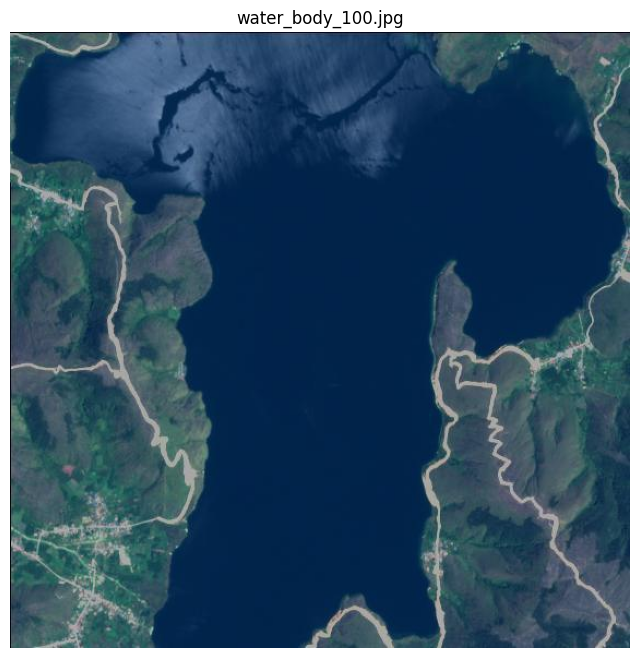

In [ ]:
#bloco11
import os
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_DIR = "/content/dataset/Water Bodies Dataset/Images"
MASK_DIR = "/content/dataset/Water Bodies Dataset/Masks"

image_files = sorted(os.listdir(IMAGE_DIR))

print("Total imagens:", len(image_files))

img_name = image_files[2]

print("Imagem escolhida:", img_name)

img_path = os.path.join(IMAGE_DIR, img_name)

image = Image.open(img_path).convert("RGB")

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.title(img_name)
plt.axis("off")
plt.show()

In [ ]:
#bloco12
import numpy as np

# converter PIL -> numpy
image_np = np.array(image)

print(image_np.shape)

(565, 568, 3)


**Bloco 13 ao bloco 40: Exploração da arquitetura**

In [ ]:
#bloco13
print(dir(model))

['TEXT_ID_FOR_GEOMETRIC', 'TEXT_ID_FOR_TEXT', 'TEXT_ID_FOR_VISUAL', 'T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_compute_matching', '_encode_prompt', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_best_mask', '_get_dummy_prompt', '_get_geo_prompt_from_find_input', '_get_img_feats', '_get_name', '_is_full_backward_hook', '_load_from_state_dict', '_load_stat

In [ ]:
#bloco14
import inspect

print(inspect.signature(model.forward_grounding))

(backbone_out, find_input, find_target, geometric_prompt: sam3.model.geometry_encoders.Prompt, **kwargs)


In [ ]:
#bloco15
print(inspect.signature(model.predict_inst))

(inference_state, **kwargs) -> Tuple[numpy.ndarray, numpy.ndarray, numpy.ndarray]


In [ ]:
#bloco16
print(dir(model.inst_interactive_predictor))

['__bool__', '__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__']


In [ ]:
#bloco17
import inspect

print(inspect.signature(model.forward))

(input: sam3.model.data_misc.BatchedDatapoint)


In [ ]:
#bloco18
import sam3
import os

print(sam3.__path__)

['/usr/local/lib/python3.12/dist-packages/sam3']


In [ ]:
#bloco19
import os
import sam3

root = sam3.__path__[0]

for path, dirs, files in os.walk(root):
    for f in files:
        if "demo" in f.lower() or "example" in f.lower():
            print(os.path.join(path, f))

/usr/local/lib/python3.12/dist-packages/sam3/eval/demo_eval.py
/usr/local/lib/python3.12/dist-packages/sam3/eval/__pycache__/demo_eval.cpython-312.pyc
/usr/local/lib/python3.12/dist-packages/sam3/model/video_tracking_multiplex_demo.py
/usr/local/lib/python3.12/dist-packages/sam3/model/__pycache__/video_tracking_multiplex_demo.cpython-312.pyc


In [ ]:
#bloco20
demo_path = "/usr/local/lib/python3.12/dist-packages/sam3/model/video_tracking_multiplex_demo.py"

with open(demo_path, "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines[:200]):
    print(f"{i+1}: {line.rstrip()}")

1: import logging
2: from collections import OrderedDict
3: from copy import deepcopy
4: from typing import Iterable, Optional
5: 
6: import numpy as np
7: import torch
8: from sam3.model.data_misc import NestedTensor
9: from sam3.model.io_utils import load_video_frames
10: from sam3.model.multiplex_utils import MultiplexState
11: from sam3.model.sam3_tracker_utils import fill_holes_in_mask_scores
12: from sam3.model.video_tracking_multiplex import (
13:     concat_points,
14:     NO_OBJ_SCORE,
15:     VideoTrackingDynamicMultiplex,
16: )
17: from tqdm import tqdm
18: 
19: 
20: class VideoTrackingMultiplexDemo(VideoTrackingDynamicMultiplex):
21:     """
22:     The demo class that extends the `VideoTrackingDynamicMultiplex` to handle user interactions
23:     and manage inference states, with support for multi-object tracking.
24: 
25:     Interactions are not yet implemented.
26:     """
27: 
28:     def __init__(
29:         self,
30:         # whether to clear non-conditioning memor

In [ ]:
#bloco21
demo_path = "/usr/local/lib/python3.12/dist-packages/sam3/model/video_tracking_multiplex_demo.py"

with open(demo_path, "r") as f:
    text = f.read()

keywords = [
    "predict_inst",
    "forward_grounding",
    "text",
    "prompt",
]

for kw in keywords:
    print(f" {kw} ")

    idx = text.find(kw)

    if idx != -1:
        start = max(0, idx - 500)
        end = idx + 1500

        print(text[start:end])
    else:
        print("não encontrado")

 predict_inst 
não encontrado
 forward_grounding 
não encontrado
 text 
não encontrado
 prompt 
        # if fill_hole_area > 0, we fill small holes in the final masks up to this area (after resizing them to the original video resolution)
        fill_hole_area=0,
        # if always_start_from_first_ann_frame is True, we always start tracking from the frame where we receive the first annotation (clicks or mask)
        # and ignore the `start_frame_idx` passed to `propagate_in_video`
        always_start_from_first_ann_frame=False,
        # the maximum number of points to be used in the prompt encoder, which reduce the domain gap between training (that only has 8 points)
        # - if it's set to a positive integer, we only take the `max_point_num_in_prompt_enc//2` points and
        #   the last `(max_point_num_in_prompt_enc - max_point_num_in_prompt_enc//2)` points in the prompt encoder
        # - if it's set to 0 or negative, this option is turned off and we use all points in th

In [ ]:
#bloco22
import numpy as np
import matplotlib.pyplot as plt

image_np = np.array(image)

h, w = image_np.shape[:2]

# ponto central automático
points = np.array([
    [w//2, h//2]
])

labels = np.array([1])

print("Imagem:", image_np.shape)
print("Ponto:", points)

Imagem: (565, 568, 3)
Ponto: [[284 282]]


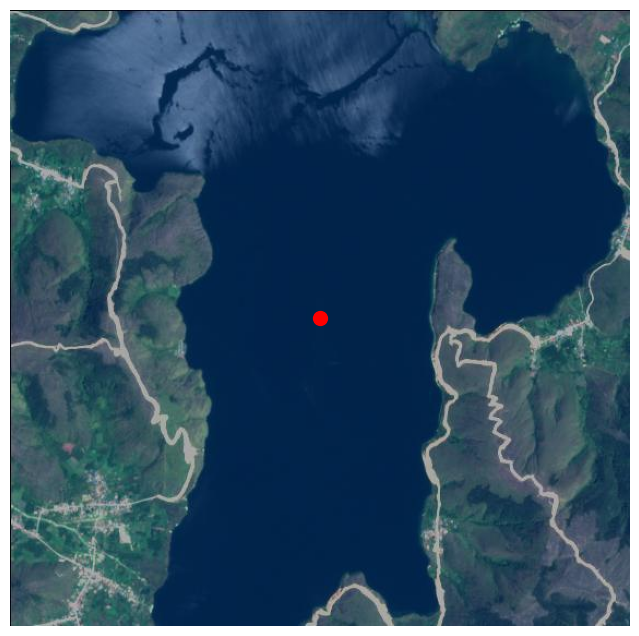

In [ ]:
#bloco23
plt.figure(figsize=(8,8))

plt.imshow(image_np)

plt.scatter(
    points[:,0],
    points[:,1],
    c='red',
    s=100
)

plt.axis("off")
plt.show()

In [ ]:
#24
import inspect

print(inspect.signature(model._encode_prompt))

(backbone_out, find_input, geometric_prompt, visual_prompt_embed=None, visual_prompt_mask=None, encode_text=True, prev_mask_pred=None)


In [ ]:
#25
import inspect

print(inspect.signature(model._run_encoder))

(backbone_out: Dict, find_input: sam3.model.data_misc.FindStage, prompt: torch.Tensor, prompt_mask: torch.Tensor, encoder_extra_kwargs: Optional[Dict] = None) -> Tuple[Dict, Dict, Tuple]


In [ ]:
#26
metodos = [m for m in dir(model) if "predict" in m.lower()]

print(metodos)

['inst_interactive_predictor', 'o2m_mask_predict', 'predict_inst', 'predict_inst_batch']


In [ ]:
#27
metodos = [m for m in dir(model) if "mask" in m.lower()]

print(metodos)

['_get_best_mask', 'multimask_output', 'o2m_mask_predict']


In [ ]:
#28
help(model.predict_inst)

Help on method predict_inst in module sam3.model.sam3_image:

predict_inst(inference_state, **kwargs) -> Tuple[numpy.ndarray, numpy.ndarray, numpy.ndarray] method of sam3.model.sam3_image.Sam3Image instance



In [ ]:
#29
import inspect

print(inspect.getsource(model.predict_inst))

    def predict_inst(
        self,
        inference_state,
        **kwargs,
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        orig_h, orig_w = (
            inference_state["original_height"],
            inference_state["original_width"],
        )
        backbone_out = inference_state["backbone_out"]["sam2_backbone_out"]
        (
            _,
            vision_feats,
            _,
            _,
        ) = self.inst_interactive_predictor.model._prepare_backbone_features(
            backbone_out
        )
        # Add no_mem_embed, which is added to the lowest rest feat. map during training on videos
        vision_feats[-1] = (
            vision_feats[-1] + self.inst_interactive_predictor.model.no_mem_embed
        )
        feats = [
            feat.permute(1, 2, 0).view(1, -1, *feat_size)
            for feat, feat_size in zip(
                vision_feats[::-1], self.inst_interactive_predictor._bb_feat_sizes[::-1]
            )
        ][::-1]
        self.

In [ ]:
#30
metodos = [m for m in dir(model) if "backbone" in m.lower()]

print(metodos)

metodos = [m for m in dir(model) if "image" in m.lower()]

print(metodos)

['backbone']
[]


In [ ]:
#31
metodos = [m for m in dir(model.inst_interactive_predictor) if "image" in m.lower()]

print(metodos)

[]


In [ ]:
#bloco32
metodos = [m for m in dir(model.inst_interactive_predictor) if "set" in m.lower()]

print(metodos)

['__setattr__']


In [ ]:
#bloco33
metodos = [m for m in dir(model.inst_interactive_predictor) if "feature" in m.lower()]

print(metodos)

[]


In [ ]:
#34
import inspect

print(inspect.signature(model.forward))

(input: sam3.model.data_misc.BatchedDatapoint)


In [ ]:
#35
from sam3.model.data_misc import BatchedDatapoint

print(BatchedDatapoint)

<class 'sam3.model.data_misc.BatchedDatapoint'>


In [ ]:
#36
import inspect

print(inspect.getsource(BatchedDatapoint))

@dataclass
class BatchedDatapoint:
    img_batch: torch.Tensor
    find_text_batch: List[str]
    find_inputs: List[FindStage]
    find_targets: List[BatchedFindTarget]
    find_metadatas: List[BatchedInferenceMetadata]
    raw_images: Optional[List[Any]] = None
    get_queries: Optional[Any] = None



In [ ]:
#37
import inspect

print(inspect.getsource(model.backbone.forward))

    def forward(
        self,
        samples: torch.Tensor,
        captions: List[str],
        input_boxes: Optional[torch.Tensor] = None,
        additional_text: Optional[List[str]] = None,
    ):
        """Forward pass of the backbone combiner.

        :param samples: The input images
        :param captions: The input captions
        :param input_boxes: If the text contains place-holders for boxes, this
            parameter contains the tensor containing their spatial features
        :param additional_text: This can be used to encode some additional text
            (different from the captions) in the same forward of the backbone
        :return: Output dictionary with the following keys:
            - vision_features: The output of the vision backbone
            - language_features: The output of the language backbone
            - language_mask: The attention mask of the language backbone
            - vision_pos_enc: The positional encoding of the vision backbone
    

In [ ]:
#38
import inspect

print(inspect.signature(model.backbone.forward_image))

(samples: torch.Tensor)


In [ ]:
#39
print(inspect.getsource(model.backbone.forward_image))

    def forward_image(self, samples: torch.Tensor):
        return activation_ckpt_wrapper(self._forward_image_no_act_ckpt)(
            samples=samples,
            act_ckpt_enable=self.act_ckpt_whole_vision_backbone and self.training,
        )



In [ ]:
#40
import inspect

print(inspect.getsource(model.backbone._forward_image_no_act_ckpt))

    def _forward_image_no_act_ckpt(self, samples):
        # Forward through backbone
        sam3_features, sam3_pos, sam2_features, sam2_pos = self.vision_backbone.forward(
            samples
        )
        if self.scalp > 0:
            # Discard the lowest resolution features
            sam3_features, sam3_pos = (
                sam3_features[: -self.scalp],
                sam3_pos[: -self.scalp],
            )
            if sam2_features is not None and sam2_pos is not None:
                sam2_features, sam2_pos = (
                    sam2_features[: -self.scalp],
                    sam2_pos[: -self.scalp],
                )

        sam2_output = None

        if sam2_features is not None and sam2_pos is not None:
            sam2_src = sam2_features[-1]
            sam2_output = {
                "vision_features": sam2_src,
                "vision_pos_enc": sam2_pos,
                "backbone_fpn": sam2_features,
            }

        sam3_src = sam3_features[-1]
 

**Blco 73 ao bloco 75: Exploração de feature maps**


In [ ]:
print("model:", next(model.parameters()).dtype)

print(
    "vision backbone:",
    next(model.backbone.vision_backbone.parameters()).dtype
)

print(
    "trunk:",
    next(model.backbone.vision_backbone.trunk.parameters()).dtype
)

model: torch.float32
vision backbone: torch.float32
trunk: torch.float32


In [ ]:
#72A

import cv2
import numpy as np
import torch

img_np = np.array(image)

img_resize = cv2.resize(img_np, (1008, 1008))

img_tensor = (
    torch.from_numpy(img_resize)
    .permute(2, 0, 1)
    .unsqueeze(0)
    .float()
    .to(device)
)

print(img_tensor.shape)
print(img_tensor.dtype)
print(img_tensor.device)

torch.Size([1, 3, 1008, 1008])
torch.float32
cuda:0


In [ ]:

#73

with torch.no_grad():

    out = model.backbone.forward_image(img_tensor)

print(out.keys())

RuntimeError: mat1 and mat2 must have the same dtype, but got BFloat16 and Float

In [ ]:
#74
print(type(out))

for k, v in out.items():

    print("\nKEY:", k)

    if isinstance(v, torch.Tensor):
        print(v.shape, v.dtype)

    elif isinstance(v, list):
        print("lista com", len(v), "elementos")

    elif isinstance(v, dict):
        print(v.keys())

    else:
        print(type(v))

In [ ]:
#75
fpn = out["backbone_fpn"]

print(type(fpn))
print(len(fpn))

for i, feat in enumerate(fpn):

    print(f"\nFPN {i}")
    print("shape:", feat.shape)
    print("dtype:", feat.dtype)

**Bloco 82 ao bloco 86: Exploração dos feature maps**

In [ ]:
#82
feat = out["backbone_fpn"][0][0]

mean_map = feat.float().mean(0).cpu().numpy()

plt.figure(figsize=(8,8))
plt.imshow(mean_map)
plt.colorbar()
plt.title("Mean activation map")
plt.show()

#83

feat = out["backbone_fpn"][0][0]

mean_map = feat.float().mean(0).cpu().numpy()

thr = np.percentile(mean_map, 85)

mask = mean_map > thr

plt.figure(figsize=(8,8))
plt.imshow(mask, cmap="gray")
plt.title("Pseudo mask - P85")
plt.show()

#84

import matplotlib.pyplot as plt

feat = out["backbone_fpn"][0][0].float().cpu()

# variância de cada canal
channel_var = feat.view(feat.shape[0], -1).var(dim=1)

best_channel = channel_var.argmax().item()

print("Canal escolhido:", best_channel)

plt.figure(figsize=(8,8))
plt.imshow(feat[best_channel].numpy())
plt.colorbar()
plt.title(f"Canal {best_channel}")
plt.axis("off")
plt.show()

#85

best_map = feat[best_channel].numpy()

thr = np.percentile(best_map, 95)

mask = best_map > thr

plt.figure(figsize=(8,8))
plt.imshow(mask, cmap="gray")
plt.title(f"Canal {best_channel} - P95")
plt.axis("off")
plt.show()

#86

import torch
import matplotlib.pyplot as plt

feat = out["backbone_fpn"][0][0].float().cpu()

channel_var = feat.view(feat.shape[0], -1).var(dim=1)

topk = torch.topk(channel_var, 9)

fig, axes = plt.subplots(3, 3, figsize=(12,12))

for ax, idx in zip(axes.flatten(), topk.indices):

    idx = idx.item()

    ax.imshow(feat[idx].numpy())

    ax.set_title(f"Canal {idx}")

    ax.axis("off")

plt.tight_layout()

plt.show()

**Bloco 87 ao bloco 89: PCA + KMeans**

In [ ]:
#87

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

feat = out["backbone_fpn"][0][0].float().cpu().numpy()

C,H,W = feat.shape

X = feat.reshape(C, -1).T

pca = PCA(n_components=3)

Y = pca.fit_transform(X)

pc1 = Y[:,0].reshape(H,W)

plt.figure(figsize=(8,8))
plt.imshow(pc1)
plt.colorbar()
plt.title("PCA - componente 1")
plt.axis("off")
plt.show()

#88

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

feat = out["backbone_fpn"][0][0].float().cpu().numpy()

C,H,W = feat.shape

X = feat.reshape(C, -1).T

kmeans = KMeans(
    n_clusters=4,
    random_state=0,
    n_init=10
)

labels = kmeans.fit_predict(X)

seg = labels.reshape(H,W)

plt.figure(figsize=(8,8))
plt.imshow(seg)
plt.colorbar()
plt.title("KMeans (4 clusters)")
plt.axis("off")
plt.show()

#89

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

feat = out["backbone_fpn"][0][0].float().cpu().numpy()

C,H,W = feat.shape

X = feat.reshape(C, -1).T

pca = PCA(n_components=8)

Xp = pca.fit_transform(X)

kmeans = KMeans(
    n_clusters=4,
    random_state=0,
    n_init=10
)

labels = kmeans.fit_predict(Xp)

seg = labels.reshape(H,W)

plt.figure(figsize=(8,8))
plt.imshow(seg)
plt.colorbar()
plt.title("PCA + KMeans")
plt.axis("off")
plt.show()

**Bloco 90 ao bloco 95: Pseudo - máscara**

In [ ]:
#90

cluster_alvo = 3

seg = labels.reshape(H, W)

pseudo_mask = (seg == cluster_alvo)

plt.figure(figsize=(8,8))
plt.imshow(pseudo_mask, cmap="gray")
plt.title(f"Pseudo máscara - cluster {cluster_alvo}")
plt.axis("off")
plt.show()

#91

fig, ax = plt.subplots(2, 2, figsize=(12,12))

for c in range(4):

    mask = (seg == c)

    ax.flat[c].imshow(mask, cmap="gray")
    ax.flat[c].set_title(f"Cluster {c}")
    ax.flat[c].axis("off")

plt.tight_layout()
plt.show()

#92

for c in range(4):

    mask = (seg == c)

    print(
        f"Cluster {c}:",
        "pixels =", mask.sum(),
        "percentual =", round(100 * mask.mean(), 2), "%"
    )

    #93

import numpy as np

unique, counts = np.unique(seg, return_counts=True)

for u, c in zip(unique, counts):

    print(
        "cluster",
        u,
        "pixels",
        c,
        "percent",
        round(100*c/seg.size,2)
    )

    #94

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow((seg == 2), cmap="gray")
ax[0].set_title("Cluster 2")
ax[0].axis("off")

ax[1].imshow((seg == 3), cmap="gray")
ax[1].set_title("Cluster 3")
ax[1].axis("off")

ax[2].imshow(((seg == 2) | (seg == 3)), cmap="gray")
ax[2].set_title("Cluster 2 + 3")
ax[2].axis("off")

plt.show()

#95

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import (
    binary_opening,
    binary_closing,
    binary_fill_holes
)

# máscara candidata
mask = ((seg == 2) | (seg == 3))

# remove pontinhos isolados
mask = binary_opening(mask, structure=np.ones((3,3)))

# fecha pequenas falhas
mask = binary_closing(mask, structure=np.ones((5,5)))

# preenche buracos internos
mask = binary_fill_holes(mask)

plt.figure(figsize=(8,8))
plt.imshow(mask, cmap="gray")
plt.title("Pseudo máscara refinada")
plt.axis("off")
plt.show()

**Bloco 96 ao bloco 98: Avaliação final**

In [ ]:
#96

print("Pixels ativos:", mask.sum())

print("Percentual da imagem:",
      round(100 * mask.sum() / mask.size, 2),
      "%")

#97

from scipy.ndimage import label
import numpy as np
import matplotlib.pyplot as plt

labels_cc, n_comp = label(mask)

sizes = np.bincount(labels_cc.ravel())

# mantém apenas componentes com mais de 100 pixels
keep = sizes > 100

keep[0] = False  # fundo

mask_clean = keep[labels_cc]

print("Componentes encontradas:", n_comp)
print("Pixels após limpeza:", mask_clean.sum())

plt.figure(figsize=(8,8))
plt.imshow(mask_clean, cmap="gray")
plt.title("Máscara limpa")
plt.axis("off")
plt.show()

#98

import cv2
import numpy as np
import matplotlib.pyplot as plt

img_np = np.array(image)

mask_vis = cv2.resize(
    mask_clean.astype(np.uint8),
    (img_np.shape[1], img_np.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

plt.figure(figsize=(10,10))

plt.imshow(img_np)

plt.imshow(mask_vis, alpha=0.4)

plt.title("Pseudo-segmentação - Imagem 2")

plt.axis("off")

plt.show()